# Dataset tutorial

This notebook walks you through loading the datasets from The Well, processing the data and using a dataset to train a simple neural network.

In [1]:
# Uncomment and run the following line to install the_well
# !pip install the_well[benchmark]

import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import rearrange
from neuralop.models import FNO
from tqdm import tqdm

from the_well.benchmark.metrics import VRMSE
from the_well.data import WellDataset
from the_well.data.normalization import (  # noqa: F401
    RMSNormalization,
    ZScoreNormalization,
)
from the_well.utils.download import well_download

#device = "mps"
base_path = "./data"  # path/to/storage

## Download data

First let's download the data relevant for this tutorial. In this notebook, we use `turbulent_radiative_layer_2D` as it is the smallest dataset in The Well.

In [2]:
# well_download(base_path=base_path, dataset="turbulent_radiative_layer_2D", split="train")

In [3]:
# well_download(base_path=base_path, dataset="turbulent_radiative_layer_2D", split="valid")

## Dataset object

To load a dataset from The Well, the easiest way is to use the `WellDataset` class.

In [2]:
dataset = WellDataset(
    well_base_path=f"{base_path}/datasets",
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="train",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=False,
)

The dataset object is an instance of a PyTorch dataset (`torch.utils.data.Dataset`). Each item in the dataset is a dictionnary that contains 6 elements.

In [4]:
item = dataset[0]

list(item.keys())

['input_fields',
 'output_fields',
 'constant_scalars',
 'boundary_conditions',
 'space_grid',
 'input_time_grid',
 'output_time_grid']

The most important elements are `input_fields` and `output_fields`. They represent the time-varying physical fields of the dynamical system and are generally the input and target of our models. For a dynamical system that has 2 spatial dimensions $x$ and $y$, `input_fields` would have a shape $(T_{in}, L_x, L_y, F)$ and `output_fields` would have a shape $(T_{out}, L_x, L_y, F)$. The number of input and output timesteps $T_{in}$ and $T_{out}$ are specified at the instantiation of the dataset with the arguments `n_steps_input` and `n_steps_output`. $L_x$ and $L_y$ are the lengths of the spatial dimensions. $F$ represents the number of physical fields, where vector fields $v = (v_x, v_y)$ and tensor fields $t = (t_{xx}, t_{xy}, t_{yx}, t_{yy})$ are flattened.

In [5]:
item["input_fields"].shape

torch.Size([4, 128, 384, 4])

In [6]:
item["output_fields"].shape

torch.Size([1, 128, 384, 4])

One can access the names of the fields in `dataset.metadata.field_names`. The names are organized by the fields' tensor-order. In this dataset, the momentum is a vector field (first-order tensor).

In [7]:
dataset.metadata.field_names

{0: ['density', 'pressure'], 1: ['velocity_x', 'velocity_y'], 2: []}

In [8]:
field_names = [
    name for group in dataset.metadata.field_names.values() for name in group
]
field_names

['density', 'pressure', 'velocity_x', 'velocity_y']

In an item, the input and output form a time-contiguous window in the trajectories. The total number of available windows in the dataset depends on the number of files, trajectories per file and timesteps per trajectory.

In [9]:
window_size = dataset.n_steps_input + dataset.n_steps_output

total_windows = 0
for i in range(dataset.metadata.n_files):
    windows_per_trajectory = (
        dataset.metadata.n_steps_per_trajectory[i] - window_size + 1
    )
    total_windows += (
        windows_per_trajectory * dataset.metadata.n_trajectories_per_file[i]
    )

print(total_windows)

6984


Conveniently, this corresponds to the length of the dataset.

In [10]:
len(dataset)

6984

## Visualize the data

The easiest way to visualize the data is to plot the fields separately. 

In [11]:
F = dataset.metadata.n_fields

In [12]:
F

4

In [13]:
%matplotlib inline

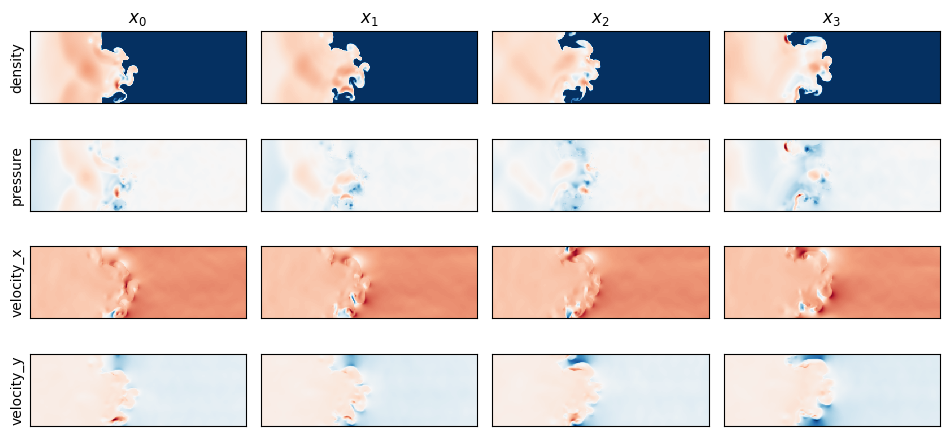

In [14]:
x = dataset[42]["input_fields"]
x = rearrange(x, "T Lx Ly F -> F T Lx Ly")

fig, axs = plt.subplots(F, 4, figsize=(4 * 2.4, F * 1.2))

for field in range(F):
    vmin = np.nanmin(x[field])
    vmax = np.nanmax(x[field])

    axs[field, 0].set_ylabel(f"{field_names[field]}")

    for t in range(4):
        axs[field, t].imshow(
            x[field, t], cmap="RdBu_r", interpolation="none", vmin=vmin, vmax=vmax
        )
        axs[field, t].set_xticks([])
        axs[field, t].set_yticks([])

        axs[0, t].set_title(f"$x_{t}$")

plt.tight_layout()

## Processing

In most datasets of The Well, some quantities are always positive and/or vary greatly in magnitude. These quantities should be preprocessed before being passed to a neural network. In this notebook, we standardize the fields with respect to their mean and standard deviation over a subset of the training set. Alternatively one could set `use_normalization=True` and `normalization_type=ZScoreNormalization` when instantiating the dataset, which would standardize the fields with respect to their mean and standard deviation over the entire training set. Another normalization option is RMSNormalization which can be set by `use_normalization=True` and `normalization_type=RMSNormalization`, which will standardize the fields with respect to the rms values over the entire training set. Note that for correctly setting the normalization, both  `use_normalization` and `normalization_type` flags must be set since the default is `use_normalization=False` and `normalization_type=None`.

In [26]:
xs = []

for i in range(0, 1000, 100):
    x = dataset[i]["input_fields"]
    xs.append(x)

xs = torch.stack(xs)

In [27]:
device = "cpu"

In [28]:
mu = xs.reshape(-1, F).mean(dim=0).to(device)
sigma = xs.reshape(-1, F).std(dim=0).to(device)

In [29]:
def preprocess(x):
    return (x - mu.to(x.device)) / sigma.to(x.device)


def postprocess(x):
    return sigma.to(x.device) * x + mu.to(x.device)

## Training

We train a small Fourier Neural Operator (FNO) to predict the $T_{out} = 1$ next states given the $T_{in} = 4$ previous states. We concatenate the input steps along their channels, such that the model expects $T_{in} \times F$ channels as input and $T_{out} \times F$ channels as output. Because `WellDataset` is a PyTorch dataset, we can use it conveniently with PyTorch data-loaders.

In [ ]:
model = FNO(
    n_modes=(16, 16),
    in_channels=4 * F,
    out_channels=1 * F,
    hidden_channels=128,
    n_layers=5,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

In [ ]:
train_loader = torch.utils.data.DataLoader(
    dataset=dataset,
    shuffle=True,
    batch_size=4,
    num_workers=4,
)

for epoch in range(1):
    for batch in (bar := tqdm(train_loader)):
        x = batch["input_fields"]
        x = x.to(device)
        x = preprocess(x)
        x = rearrange(x, "B Ti Lx Ly F -> B (Ti F) Lx Ly")

        y = batch["output_fields"]
        y = y.to(device)
        y = preprocess(y)
        y = rearrange(y, "B To Lx Ly F -> B (To F) Lx Ly")

        fx = model(x)

        mse = (fx - y).square().mean()
        mse.backward()

        optimizer.step()
        optimizer.zero_grad()

        bar.set_postfix(loss=mse.detach().item())

  0%|          | 0/1746 [00:00<?, ?it/s]

/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [4, 128, 128, 193]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [4, 128, 128, 384]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized 

## Evaluation

Now that our model is trained, we can use it to make predictions. We evaluate the prediction with the variance-scaled root mean squared error (VRMSE) per field. In the manuscript, we report the VRMSE averaged over all fields.

In [41]:
from the_well.benchmark.models import FNO

model = FNO.from_pretrained("polymathic-ai/FNO-turbulent_radiative_layer_2D")


In [55]:
validset = WellDataset(
    well_base_path=f"{base_path}/datasets",
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="valid",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=False
)

In [56]:
item = validset[123]

x = item["input_fields"]

In [43]:
item = validset[123]

x = item["input_fields"]
x = x.to(device)
x = preprocess(x)
x = rearrange(x, "Ti Lx Ly F -> 1 (Ti F) Lx Ly")

y = item["output_fields"]
y = y.to(device)

with torch.no_grad():
    fx = model(x)
    fx = rearrange(fx, "1 (To F) Lx Ly -> To Lx Ly F", F=F)
    fx = postprocess(fx)

VRMSE.eval(fx, y, meta=validset.metadata)

tensor([[1.6681, 2.5523, 1.0667, 1.0812]])

$\text{RMSE} = \sqrt{\mathbb{E}[(\hat y - y)^2]}$

$\text{VRMSE} = \sqrt{\frac{\mathbb{E}[(\hat y - y)^2]}{\mathrm{Var}(y)}}$

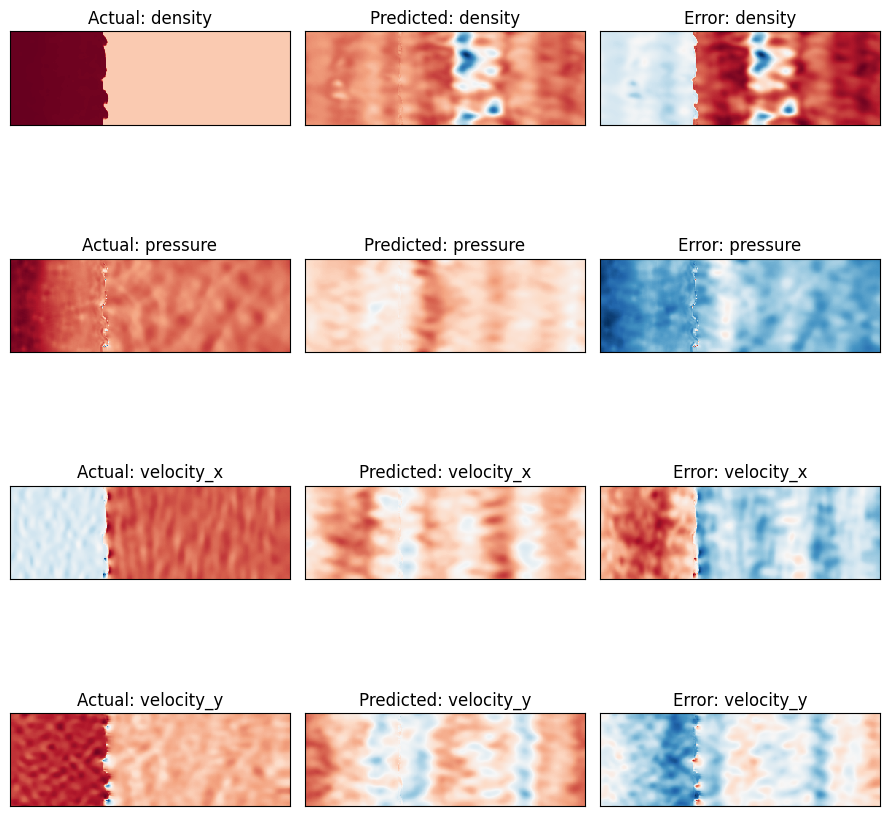

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from einops import rearrange

field_names = [
    name for group in validset.metadata.field_names.values() for name in group
]

# move to cpu for plotting
y_plot = y.detach().cpu()
fx_plot = fx.detach().cpu()

# take first output timestep: shape becomes (Lx, Ly, F)
y0 = y_plot[0]
fx0 = fx_plot[0]

# rearrange to (F, Lx, Ly) so we can loop over fields
y0 = rearrange(y0, "Lx Ly F -> F Lx Ly")
fx0 = rearrange(fx0, "Lx Ly F -> F Lx Ly")

F = y0.shape[0]
fig, axs = plt.subplots(F, 3, figsize=(9, 2.5 * F))

if F == 1:
    axs = np.expand_dims(axs, axis=0)

for f in range(F):
    vmin = min(y0[f].min().item(), fx0[f].min().item())
    vmax = max(y0[f].max().item(), fx0[f].max().item())

    axs[f, 0].imshow(y0[f], cmap="RdBu_r", interpolation="none", vmin=vmin, vmax=vmax)
    axs[f, 0].set_title(f"Actual: {field_names[f]}")
    axs[f, 0].set_xticks([])
    axs[f, 0].set_yticks([])

    axs[f, 1].imshow(fx0[f], cmap="RdBu_r", interpolation="none", vmin=vmin, vmax=vmax)
    axs[f, 1].set_title(f"Predicted: {field_names[f]}")
    axs[f, 1].set_xticks([])
    axs[f, 1].set_yticks([])

    diff = fx0[f] - y0[f]
    axs[f, 2].imshow(diff, cmap="RdBu_r", interpolation="none")
    axs[f, 2].set_title(f"Error: {field_names[f]}")
    axs[f, 2].set_xticks([])
    axs[f, 2].set_yticks([])

plt.tight_layout()
plt.show()

# Rollout prediction

In [27]:
def rollout_predict(model, item, horizon, device, preprocess, postprocess, F):
    """
    Autoregressive rollout for a one-step model.

    Args:
        item["input_fields"]:  (Ti, Lx, Ly, F)
        item["output_fields"]: (horizon, Lx, Ly, F) or longer
    Returns:
        preds:  (horizon, Lx, Ly, F)
        actual: (horizon, Lx, Ly, F)
    """
    context = item["input_fields"].clone().to(device)
    actual = item["output_fields"][:horizon].to(device)

    preds = []
    model.eval()

    with torch.no_grad():
        for _ in range(horizon):
            x = preprocess(context)
            x = rearrange(x, "Ti Lx Ly F -> 1 (Ti F) Lx Ly")

            pred = model(x)
            pred = rearrange(pred, "1 (To F) Lx Ly -> To Lx Ly F", F=F)
            pred = postprocess(pred)

            # your model is trained with n_steps_output=1, so take the first predicted frame
            next_frame = pred[0]  # (Lx, Ly, F)
            preds.append(next_frame)

            # slide the input window forward
            context = torch.cat([context[1:], next_frame.unsqueeze(0)], dim=0)

    preds = torch.stack(preds, dim=0)
    return preds, actual


def plot_rollout(preds, actual, field_names, field_idx=0, steps=None, cmap="RdBu_r"):
    """
    Plot predicted vs actual for one chosen field over several rollout steps.
    """
    preds = preds.detach().cpu()
    actual = actual.detach().cpu()

    if steps is None:
        steps = list(range(min(5, preds.shape[0])))

    n = len(steps)
    fig, axs = plt.subplots(n, 3, figsize=(9, 3 * n))

    if n == 1:
        axs = np.expand_dims(axs, axis=0)

    for row, t in enumerate(steps):
        pred = preds[t, :, :, field_idx]
        true = actual[t, :, :, field_idx]
        err = pred - true

        vmin = min(pred.min().item(), true.min().item())
        vmax = max(pred.max().item(), true.max().item())

        axs[row, 0].imshow(true, cmap=cmap, interpolation="none", vmin=vmin, vmax=vmax)
        axs[row, 0].set_title(f"Actual t={t+1}")

        axs[row, 1].imshow(pred, cmap=cmap, interpolation="none", vmin=vmin, vmax=vmax)
        axs[row, 1].set_title(f"Predicted t={t+1}")

        axs[row, 2].imshow(err, cmap=cmap, interpolation="none")
        axs[row, 2].set_title(f"Error t={t+1}")

        for col in range(3):
            axs[row, col].set_xticks([])
            axs[row, col].set_yticks([])

    fig.suptitle(f"Rollout for field: {field_names[field_idx]}", y=1.02)
    plt.tight_layout()
    plt.show()

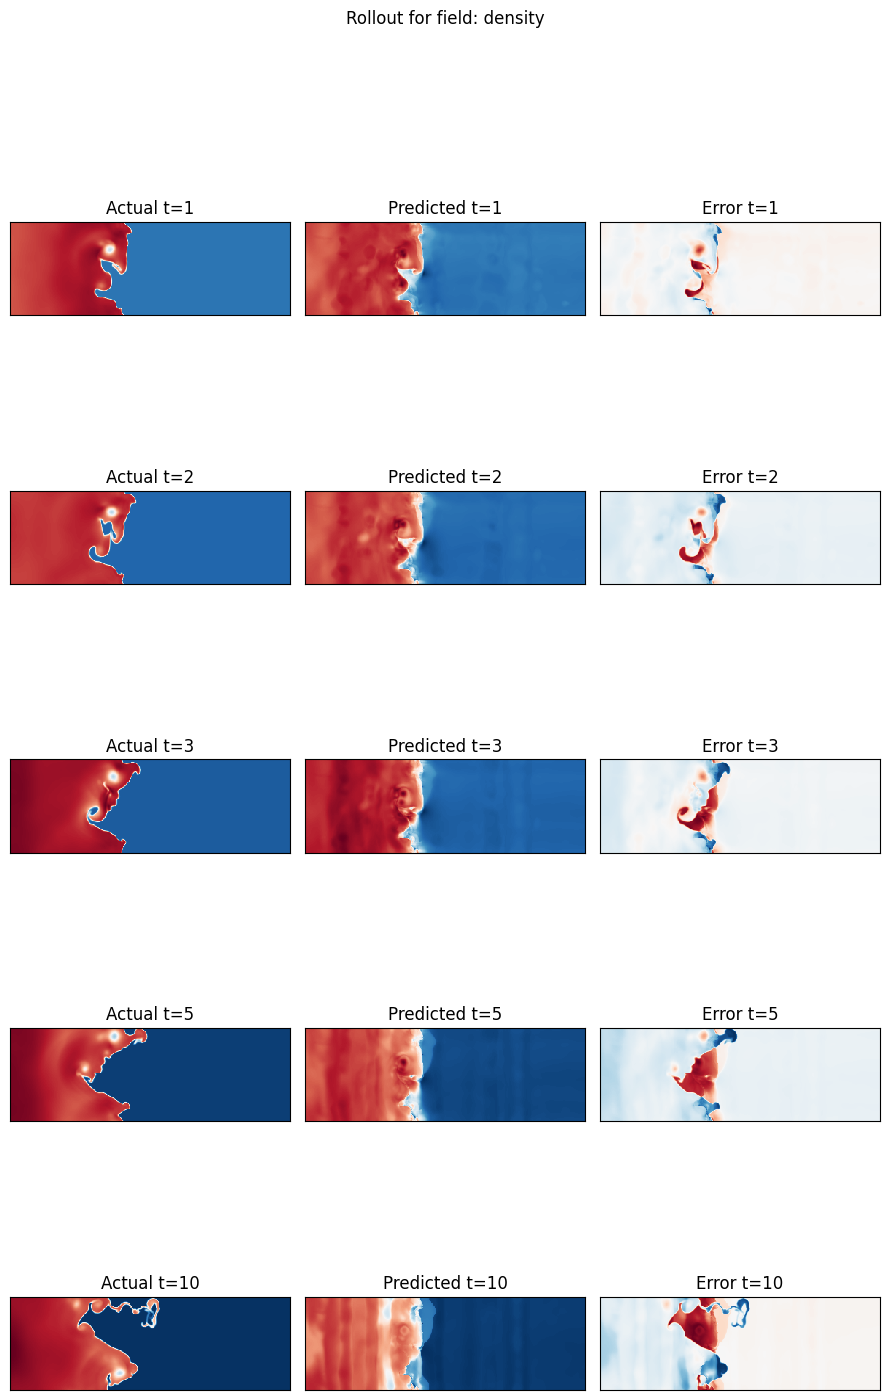

In [29]:
horizon = 10

rollout_validset = WellDataset(
    well_base_path=f"{base_path}/datasets",
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="valid",
    n_steps_input=4,
    n_steps_output=horizon,
    use_normalization=False,
)

field_names = [
    name for group in rollout_validset.metadata.field_names.values() for name in group
]

item = rollout_validset[123]

preds, actual = rollout_predict(
    model=model,
    item=item,
    horizon=horizon,
    device=device,
    preprocess=preprocess,
    postprocess=postprocess,
    F=F,
)

plot_rollout(
    preds,
    actual,
    field_names=field_names,
    field_idx=0,          # 0=density, 1=pressure, 2=velocity_x, 3=velocity_y
    steps=[0, 1, 2, 4, 9]
)

In [30]:
VRMSE.eval(preds, actual, meta=rollout_validset.metadata)

tensor([[0.2292, 0.8718, 0.2951, 0.6515],
        [0.3237, 1.3205, 0.3474, 0.9076],
        [0.3613, 1.4799, 0.3241, 0.9989],
        [0.4061, 1.6311, 0.3817, 1.0884],
        [0.4444, 1.5709, 0.3836, 1.0812],
        [0.4734, 1.5408, 0.4408, 1.0803],
        [0.4898, 1.3559, 0.5241, 1.0934],
        [0.4980, 1.2870, 0.5809, 1.0680],
        [0.4849, 1.3934, 0.6898, 1.0672],
        [0.4700, 1.5278, 0.6703, 1.0279]], device='mps:0')

In [34]:
vrmse_per_field = VRMSE.eval(preds, actual, meta=rollout_validset.metadata).mean(dim=0)
print(vrmse_per_field)  # shape: (F,)

tensor([0.4181, 1.3979, 0.4638, 1.0064], device='mps:0')


In [35]:
field_names = [
    name for group in rollout_validset.metadata.field_names.values() for name in group
]

for name, val in zip(field_names, vrmse_per_field):
    print(name, val.item())

density 0.41807612776756287
pressure 1.397924542427063
velocity_x 0.4637879431247711
velocity_y 1.0064399242401123


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def save_rollout_gif(
    preds,
    actual,
    field_names,
    save_path="rollout.gif",
    cmap="RdBu_r",
    fps=2,
):
    """
    Save a GIF comparing actual rollout vs predicted rollout.

    Args:
        preds:   torch.Tensor or np.ndarray, shape (T, Lx, Ly, F)
        actual:  torch.Tensor or np.ndarray, shape (T, Lx, Ly, F)
        field_names: list of length F
        save_path: output gif path
        cmap: matplotlib colormap
        fps: frames per second
    """
    if hasattr(preds, "detach"):
        preds = preds.detach().cpu().numpy()
    if hasattr(actual, "detach"):
        actual = actual.detach().cpu().numpy()

    T, Lx, Ly, F = preds.shape

    fig, axs = plt.subplots(F, 3, figsize=(9, 2.8 * F))
    if F == 1:
        axs = np.expand_dims(axs, axis=0)

    # Precompute common color limits for actual/pred per field
    value_limits = []
    error_limits = []
    for f in range(F):
        vmin = min(actual[..., f].min(), preds[..., f].min())
        vmax = max(actual[..., f].max(), preds[..., f].max())
        emax = np.max(np.abs(preds[..., f] - actual[..., f]))
        value_limits.append((vmin, vmax))
        error_limits.append((-emax, emax))

    images = []

    for f in range(F):
        vmin, vmax = value_limits[f]
        emin, emax = error_limits[f]

        im_true = axs[f, 0].imshow(actual[0, :, :, f], cmap=cmap, vmin=vmin, vmax=vmax, interpolation="none")
        im_pred = axs[f, 1].imshow(preds[0, :, :, f], cmap=cmap, vmin=vmin, vmax=vmax, interpolation="none")
        im_err = axs[f, 2].imshow(preds[0, :, :, f] - actual[0, :, :, f], cmap=cmap, vmin=emin, vmax=emax, interpolation="none")

        axs[f, 0].set_ylabel(field_names[f])
        axs[f, 0].set_xticks([])
        axs[f, 0].set_yticks([])
        axs[f, 1].set_xticks([])
        axs[f, 1].set_yticks([])
        axs[f, 2].set_xticks([])
        axs[f, 2].set_yticks([])

        if f == 0:
            axs[f, 0].set_title("Actual")
            axs[f, 1].set_title("Predicted")
            axs[f, 2].set_title("Error")

        images.append((im_true, im_pred, im_err))

    def update(t):
        fig.suptitle(f"Rollout step {t+1}/{T}")
        artists = []
        for f in range(F):
            im_true, im_pred, im_err = images[f]
            im_true.set_data(actual[t, :, :, f])
            im_pred.set_data(preds[t, :, :, f])
            im_err.set_data(preds[t, :, :, f] - actual[t, :, :, f])
            artists.extend([im_true, im_pred, im_err])
        return artists

    anim = FuncAnimation(fig, update, frames=T, interval=1000 // fps, blit=False)
    plt.tight_layout()
    anim.save(save_path, writer=PillowWriter(fps=fps))
    plt.close(fig)

In [ ]:
field_names = [
    name for group in rollout_validset.metadata.field_names.values() for name in group
]

preds, actual = rollout_predict(
    model=model,
    item=item,
    horizon=10,
    device=device,
    preprocess=preprocess,
    postprocess=postprocess,
    F=F,
)

save_rollout_gif(
    preds,
    actual,
    field_names=field_names,
    save_path="rollout.gif",
    fps=2,
)

/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 128, 128, 193]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 128, 128, 384]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized 

# Authors model

In [44]:
from the_well.benchmark.models import FNO

model = FNO.from_pretrained("polymathic-ai/FNO-turbulent_radiative_layer_2D")


In [47]:
testset = WellDataset(
    well_base_path=f"{base_path}/datasets",
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="test",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=True,
    normalization_type=ZScoreNormalization
)

In [ ]:
mean_full = testset.norm.flattened_means["variable"]          # (F,)
std_full  = testset.norm.flattened_stds["variable"]          # (F,)
mean_d    = testset.norm.flattened_means_delta["variable"]   # (F,)
std_d     = testset.norm.flattened_stds_delta["variable"]     # (F,)

In [45]:
device = 'cpu'

In [49]:
item = testset[0]

x = item["input_fields"]
x = x.to(device)
x = preprocess(x)
x = rearrange(x, "Ti Lx Ly F -> 1 (Ti F) Lx Ly")

y = item["output_fields"]
y = y.to(device)

with torch.no_grad():
    fx = model(x)
    fx = rearrange(fx, "1 (To F) Lx Ly -> To Lx Ly F", F=F)
    fx = postprocess(fx)

VRMSE.eval(fx, y, meta=validset.metadata)

/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return self.__class__(self.tensor[indices])
/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/neuralop/layers/spectral_convolution.py:459: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered 

tensor([[1.9637e+03, 3.5034e+00, 1.0868e+00, 3.6454e+00]])

In [5]:
import torch
from torch.utils.data import DataLoader
from einops import rearrange
from tqdm import tqdm
from the_well.benchmark.models import FNO
from the_well.benchmark.metrics import VRMSE
from the_well.data import WellDataset
from the_well.data.normalization import ZScoreNormalization

# 1) CPU, not MPS
device = torch.device("cpu")

# 2) Load from HuggingFace — guarantees real weights
model = FNO.from_pretrained("polymathic-ai/FNO-turbulent_radiative_layer_2D")
model = model.to(device)
model.eval()

testset_eval = WellDataset(
    well_base_path=f"{base_path}/datasets",
    well_dataset_name="turbulent_radiative_layer_2D",
    well_split_name="test",
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=True,
    normalization_type=ZScoreNormalization,
)

loader = DataLoader(testset_eval, batch_size=8, shuffle=False)
all_errors = []

with torch.no_grad():
    for batch in tqdm(loader, desc="Evaluating"):
        x = batch["input_fields"].to(device)
        y = batch["output_fields"].to(device)

        x = rearrange(x, "B Ti Lx Ly F -> B (Ti F) Lx Ly")
        pred = model(x)
        pred = rearrange(
            pred, "B (To F) Lx Ly -> B To Lx Ly F",
            To=testset_eval.n_steps_output,
            F=testset_eval.metadata.n_fields,
        )
        err = VRMSE.eval(pred, y, meta=testset_eval.metadata)
        all_errors.append(err.cpu())

errors = torch.cat(all_errors, dim=0)
print(f"Test VRMSE: {errors.mean().item():.4f}")

Evaluating:   0%|          | 0/110 [00:00<?, ?it/s]/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return self.__class__(self.tensor[indices])
/Users/emilfahretdinov/msc_hse/.venv/lib/python3.14/site-packages/neuralop/layers/spectral_convolution.py:459: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result e

Test VRMSE: 2.0101


In [ ]:
import torch
from torch.utils.data import DataLoader
from einops import rearrange
from tqdm import tqdm
from the_well.benchmark.models import FNO
from the_well.data import WellDataset
from the_well.data.normalization import ZScoreNormalization
from the_well.benchmark.metrics import VRMSE

base_path='./data'
device=torch.device('cpu')
model = FNO.from_pretrained('polymathic-ai/FNO-turbulent_radiative_layer_2D').to(device).eval()

dset = WellDataset(
    well_base_path=f'{base_path}/datasets',
    well_dataset_name='turbulent_radiative_layer_2D',
    well_split_name='test',
    n_steps_input=4,
    n_steps_output=1,
    use_normalization=True,
    normalization_type=ZScoreNormalization,
)
loader = DataLoader(dset, batch_size=8, shuffle=False)
F = dset.metadata.n_fields
norm = dset.norm
mean_full = norm.flattened_means['variable'].to(device)       # (F,)
std_full  = norm.flattened_stds['variable'].to(device)
mean_d    = norm.flattened_means_delta['variable'].to(device)
std_d     = norm.flattened_stds_delta['variable'].to(device)

sum_err2 = torch.zeros(F, device=device)
sum_y = torch.zeros(F, device=device)
sum_y2 = torch.zeros(F, device=device)
count = 0

with torch.no_grad():
    for batch in tqdm(loader, desc='stream accum'):
        x = batch['input_fields'].to(device)
        y = batch['output_fields'].to(device)
        # model expects normalized inputs already because dset uses normalization
        x_in = rearrange(x, 'B Ti Lx Ly F -> B (Ti F) Lx Ly')
        pred = model(x_in)
        pred = rearrange(pred, 'B (To F) Lx Ly -> B To Lx Ly F', To=1, F=F)

        last_input_full_norm = x[:, -1]      # (B,Lx,Ly,F) normalized full
        pred_delta_norm = pred[:, 0]         # (B,Lx,Ly,F) delta normalized

        # delta -> full normalized inversion
        last_raw = last_input_full_norm * std_full + mean_full
        delta_raw = pred_delta_norm * std_d + mean_d
        full_raw = last_raw + delta_raw
        pred_full_norm = (full_raw - mean_full) / std_full
        pred_full_norm = pred_full_norm.unsqueeze(1)  # (B,To=1,Lx,Ly,F)

        err2 = (pred_full_norm - y) ** 2  # (B,1,Lx,Ly,F)

        sum_err2 += err2.sum(dim=(0,1,2,3))
        sum_y += y.sum(dim=(0,1,2,3))
        sum_y2 += (y*y).sum(dim=(0,1,2,3))
        count += y.shape[0] * y.shape[1] * y.shape[2] * y.shape[3]

mse_f = sum_err2 / count
Ey_f = sum_y / count
Ey2_f = sum_y2 / count
Var_f = Ey2_f - Ey_f*Ey_f

vrmse_per_field = torch.sqrt(mse_f / (Var_f + 1e-7))
vrmse_mean_fields = vrmse_per_field.mean()

# Variant: compute MSE and Var after averaging over fields first
mse_mean = mse_f.mean()
Var_mean = Var_f.mean()
vrmse_fields_averaged_then_sqrt = torch.sqrt(mse_mean / (Var_mean + 1e-7))

# Variant: flatten fields too (treat each field equally by summing and dividing by F)
vrmse_flattened = torch.sqrt((mse_f.sum()) / (Var_f.sum() + 1e-7))

print('per-field VRMSE:', vrmse_per_field.tolist())
print('mean(per-field VRMSE):', vrmse_mean_fields.item())
print('sqrt(mean MSE / mean Var):', vrmse_fields_averaged_then_sqrt.item())
print('sqrt(sum MSE / sum Var):', vrmse_flattened.item())